ESCENARIO 01 CLAUDE - CON REGLAS, VERSIÓN PAGA

  AVANCE FÍSICO E INDICADORES DE CONTROL (EVM) - OBRA STAP

1) AVANCE FÍSICO CONSOLIDADO
   61.14 %

2) AVANCE POR DISCIPLINA
   - Civil                  87.39 %
   - Eléctrica              51.46 %
   - Instrumentación        31.42 %
   - Mecánica estática      69.27 %
   - Rotativa               26.21 %

3) INDICADORES DE VALOR GANADO (EVM)
   PV (Valor planificado) : 39,520,591.76 USD
   EV (Valor ganado)      : 33,947,130.85 USD
   AC (Costo real)        : 35,031,285.00 USD
   SPI (EV / PV)          : 0.859
   CPI (EV / AC)          : 0.969

4) INTERPRETACIÓN
   Cronograma : Atraso respecto al cronograma (SPI = 0.859 < 1).
   Costos     : Sobrecosto (CPI = 0.969 < 1).

5) INCONSISTENCIAS DETECTADAS
   Total: 7 inconsistencia(s).
   - [id=STAP-ELE-019] id_actividad duplicado
   - [id=STAP-CIV-005] cantidad_ejecutada > cantidad_planificada
   - [id=STAP-CIV-030] unidad no reconocida: m^3
   - [id=STAP-MEC-012] cantidad_ejecutada > cantidad_planificada
   - [id=STAP-INS-009] unidad no 

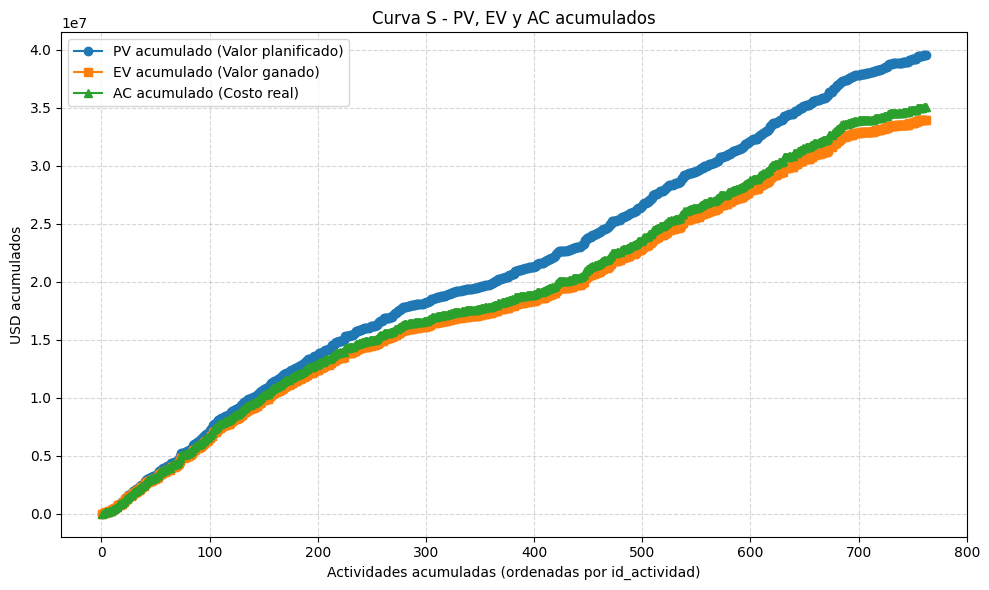

In [1]:
# -*- coding: utf-8 -*-
"""
Cálculo de avance físico e indicadores de control (EVM) de una obra de construcción.
Listo para pegar y ejecutar en una celda de Google Colab (sin argumentos de línea de comandos).

Entrada : 02_Dataset_Base_STAP.csv  (UTF-8, separado por comas, en la misma carpeta)
Columnas: id_actividad, disciplina, descripcion, unidad, cantidad_planificada,
          cantidad_ejecutada, peso_presupuesto_usd, avance_planificado_pct, costo_real_usd
Requiere: pandas, matplotlib
"""

import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------------------------------------------------
# CONFIGURACIÓN
# ----------------------------------------------------------------------
ARCHIVO = "02_Dataset_Base_STAP.csv"

UNIDADES_VALIDAS = {"pulg_diam", "kg", "m", "m2", "m3", "und"}
DISCIPLINAS_VALIDAS = {"Civil", "Mecánica estática", "Rotativa",
                       "Instrumentación", "Eléctrica"}

COLUMNAS_ESPERADAS = [
    "id_actividad", "disciplina", "descripcion", "unidad",
    "cantidad_planificada", "cantidad_ejecutada", "peso_presupuesto_usd",
    "avance_planificado_pct", "costo_real_usd",
]

COLUMNAS_NUMERICAS = [
    "cantidad_planificada", "cantidad_ejecutada", "peso_presupuesto_usd",
    "avance_planificado_pct", "costo_real_usd",
]


# ----------------------------------------------------------------------
# CARGA DE DATOS
# ----------------------------------------------------------------------
def cargar_datos(ruta):
    df = pd.read_csv(ruta, encoding="utf-8", sep=",")

    # Avisar si falta alguna columna esperada (sin detener la ejecución)
    faltantes = [c for c in COLUMNAS_ESPERADAS if c not in df.columns]
    if faltantes:
        print("ADVERTENCIA: columnas ausentes en el archivo -> " + ", ".join(faltantes))
        for c in faltantes:
            df[c] = pd.NA

    # Coerción numérica: los valores no válidos quedan como NaN (ausentes)
    for c in COLUMNAS_NUMERICAS:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    # Normalizar textos para comparación de catálogos
    for c in ["disciplina", "unidad"]:
        df[c] = df[c].astype("string").str.strip()

    return df


# ----------------------------------------------------------------------
# REGLA 1: avance por actividad = ejecutada / planificada, acotado a [0, 1]
# ----------------------------------------------------------------------
def avance_actividad(row):
    plan = row["cantidad_planificada"]
    ejec = row["cantidad_ejecutada"]
    if pd.isna(plan) or pd.isna(ejec) or plan == 0:
        return 0.0
    avance = ejec / plan
    if avance < 0:
        return 0.0
    if avance > 1:
        return 1.0
    return avance


# ----------------------------------------------------------------------
# REGLA 2: avance físico consolidado ponderado por peso presupuestal
# ----------------------------------------------------------------------
def avance_consolidado(df):
    num = (df["avance_i"] * df["peso_presupuesto_usd"]).sum()
    den = df["peso_presupuesto_usd"].sum()
    if den == 0 or pd.isna(den):
        return 0.0
    return num / den


# ----------------------------------------------------------------------
# REGLA 3: avance por disciplina (misma fórmula, agrupando por disciplina)
# ----------------------------------------------------------------------
def avance_por_disciplina(df):
    resultado = {}
    for disciplina, grupo in df.groupby("disciplina", dropna=False):
        num = (grupo["avance_i"] * grupo["peso_presupuesto_usd"]).sum()
        den = grupo["peso_presupuesto_usd"].sum()
        resultado[disciplina] = (num / den) if (den not in (0,) and not pd.isna(den)) else 0.0
    return resultado


# ----------------------------------------------------------------------
# REGLA 4: valor ganado (EVM)
# ----------------------------------------------------------------------
def calcular_evm(df):
    PV = (df["peso_presupuesto_usd"] * df["avance_planificado_pct"]).sum()
    EV = (df["peso_presupuesto_usd"] * df["avance_i"]).sum()
    AC = df["costo_real_usd"].sum()

    SPI = (EV / PV) if (PV not in (0,) and not pd.isna(PV) and PV != 0) else None
    CPI = (EV / AC) if (AC not in (0,) and not pd.isna(AC) and AC != 0) else None
    return PV, EV, AC, SPI, CPI


# ----------------------------------------------------------------------
# REGLA 5: curva S con PV, EV y AC acumulados
# (el dataset no tiene eje temporal; se acumula por actividad ordenada por id)
# ----------------------------------------------------------------------
def graficar_curva_s(df):
    d = df.sort_values("id_actividad").reset_index(drop=True)

    pv_i = (d["peso_presupuesto_usd"] * d["avance_planificado_pct"]).fillna(0)
    ev_i = (d["peso_presupuesto_usd"] * d["avance_i"]).fillna(0)
    ac_i = d["costo_real_usd"].fillna(0)

    pv_cum = pv_i.cumsum()
    ev_cum = ev_i.cumsum()
    ac_cum = ac_i.cumsum()

    x = range(1, len(d) + 1)

    plt.figure(figsize=(10, 6))
    plt.plot(x, pv_cum, marker="o", label="PV acumulado (Valor planificado)")
    plt.plot(x, ev_cum, marker="s", label="EV acumulado (Valor ganado)")
    plt.plot(x, ac_cum, marker="^", label="AC acumulado (Costo real)")
    plt.title("Curva S - PV, EV y AC acumulados")
    plt.xlabel("Actividades acumuladas (ordenadas por id_actividad)")
    plt.ylabel("USD acumulados")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.legend()
    plt.tight_layout()
    plt.show()


# ----------------------------------------------------------------------
# VALIDACIONES (se reportan sin detener el programa)
# ----------------------------------------------------------------------
def detectar_inconsistencias(df):
    inconsistencias = []  # lista de tuplas (id_actividad, mensaje)

    # id_actividad duplicado
    duplicados = df[df.duplicated("id_actividad", keep=False)]
    for idv in duplicados["id_actividad"].dropna().unique():
        inconsistencias.append((idv, "id_actividad duplicado"))

    for _, row in df.iterrows():
        idv = row["id_actividad"]

        # cantidad ejecutada mayor que la planificada
        if (pd.notna(row["cantidad_ejecutada"]) and pd.notna(row["cantidad_planificada"])
                and row["cantidad_ejecutada"] > row["cantidad_planificada"]):
            inconsistencias.append((idv, "cantidad_ejecutada > cantidad_planificada"))

        # peso presupuestal nulo, negativo o ausente
        peso = row["peso_presupuesto_usd"]
        if pd.isna(peso) or peso <= 0:
            inconsistencias.append((idv, "peso_presupuesto_usd nulo, negativo o ausente"))

        # unidad no reconocida
        unidad = row["unidad"]
        if pd.isna(unidad) or unidad not in UNIDADES_VALIDAS:
            inconsistencias.append((idv, "unidad no reconocida: {}".format(unidad)))

        # disciplina no reconocida
        disciplina = row["disciplina"]
        if pd.isna(disciplina) or disciplina not in DISCIPLINAS_VALIDAS:
            inconsistencias.append((idv, "disciplina no reconocida: {}".format(disciplina)))

        # avance_planificado_pct fuera del rango [0, 1]
        app = row["avance_planificado_pct"]
        if pd.isna(app) or app < 0 or app > 1:
            inconsistencias.append((idv, "avance_planificado_pct fuera de rango [0, 1]"))

    return inconsistencias


# ----------------------------------------------------------------------
# INTERPRETACIÓN TEXTUAL DE INDICADORES
# ----------------------------------------------------------------------
def interpretar_spi(spi):
    if spi is None:
        return "SPI no calculable (PV = 0)."
    if spi > 1:
        return "Adelanto respecto al cronograma (SPI = {:.3f} > 1).".format(spi)
    if spi < 1:
        return "Atraso respecto al cronograma (SPI = {:.3f} < 1).".format(spi)
    return "Ejecución en línea con el cronograma (SPI = 1)."


def interpretar_cpi(cpi):
    if cpi is None:
        return "CPI no calculable (AC = 0)."
    if cpi > 1:
        return "Ahorro / eficiencia en costos (CPI = {:.3f} > 1).".format(cpi)
    if cpi < 1:
        return "Sobrecosto (CPI = {:.3f} < 1).".format(cpi)
    return "Ejecución en línea con el presupuesto (CPI = 1)."


# ----------------------------------------------------------------------
# PROGRAMA PRINCIPAL
# ----------------------------------------------------------------------
def main():
    try:
        df = cargar_datos(ARCHIVO)
    except FileNotFoundError:
        print("ERROR: no se encontró el archivo '{}'.".format(ARCHIVO))
        print("Súbelo a la misma carpeta del notebook y vuelve a ejecutar.")
        return

    # Regla 1: avance por actividad
    df["avance_i"] = df.apply(avance_actividad, axis=1)

    # Reglas 2 y 3
    consolidado = avance_consolidado(df)
    por_disciplina = avance_por_disciplina(df)

    # Regla 4
    PV, EV, AC, SPI, CPI = calcular_evm(df)

    # ------------------ SALIDA POR PANTALLA ------------------
    print("=" * 64)
    print("  AVANCE FÍSICO E INDICADORES DE CONTROL (EVM) - OBRA STAP")
    print("=" * 64)

    print("\n1) AVANCE FÍSICO CONSOLIDADO")
    print("   {:.2f} %".format(consolidado * 100))

    print("\n2) AVANCE POR DISCIPLINA")
    for disciplina, valor in sorted(por_disciplina.items(),
                                    key=lambda kv: str(kv[0])):
        nombre = "(sin disciplina)" if pd.isna(disciplina) else disciplina
        print("   - {:<20} {:>7.2f} %".format(nombre, valor * 100))

    print("\n3) INDICADORES DE VALOR GANADO (EVM)")
    print("   PV (Valor planificado) : {:,.2f} USD".format(PV if pd.notna(PV) else 0))
    print("   EV (Valor ganado)      : {:,.2f} USD".format(EV if pd.notna(EV) else 0))
    print("   AC (Costo real)        : {:,.2f} USD".format(AC if pd.notna(AC) else 0))
    print("   SPI (EV / PV)          : {}".format(
        "{:.3f}".format(SPI) if SPI is not None else "N/A"))
    print("   CPI (EV / AC)          : {}".format(
        "{:.3f}".format(CPI) if CPI is not None else "N/A"))

    print("\n4) INTERPRETACIÓN")
    print("   Cronograma : " + interpretar_spi(SPI))
    print("   Costos     : " + interpretar_cpi(CPI))

    # ------------------ VALIDACIONES ------------------
    inconsistencias = detectar_inconsistencias(df)
    print("\n5) INCONSISTENCIAS DETECTADAS")
    if not inconsistencias:
        print("   No se detectaron inconsistencias.")
    else:
        print("   Total: {} inconsistencia(s).".format(len(inconsistencias)))
        for idv, mensaje in inconsistencias:
            id_txt = "(id ausente)" if pd.isna(idv) else str(idv)
            print("   - [id={}] {}".format(id_txt, mensaje))

    # ------------------ CURVA S ------------------
    print("\n6) CURVA S (PV, EV, AC acumulados)")
    graficar_curva_s(df)


# En Colab / Jupyter basta con llamar a main() directamente
main()